<a href="https://colab.research.google.com/github/sgruyzcki/DiploDatos2026/blob/main/Aprendizaje%20Supervisado/Practico%201/validation_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
# Librerias usadas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import recall_score, ConfusionMatrixDisplay, classification_report, precision_score, accuracy_score, balanced_accuracy_score, f1_score
from sklearn.decomposition import PCA
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [22]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import QuantileTransformer

## Validación Adversaria

La causa número uno por la que el CV local supera al Test de Kaggle es que el conjunto de Test tiene características estadísticamente distintas al conjunto de Train. Quizás las fotos de Test tienen otra iluminación, otras resoluciones, o una proporción distinta de clases.

Validación Adversaria (Adversarial Validation).

- Unes tu X_train y tu X_test en un solo dataset.

- Borras tu variable clase (ccb/csb).

- Creas una nueva variable objetivo es_test: le pones 0 a las filas que venían de Train y 1 a las que venían de Test.

- Entrenas un modelo simple (como Random Forest o XGBoost) para que intente predecir si una fila pertenece al Test o al Train.

**Diagnóstico:** Si el modelo obtiene un accuracy cercano al 50%, significa que no puede distinguirlos (Train y Test son estadísticamente idénticos; tu bajón de score es pura mala suerte en ese 26%). Si el modelo obtiene un 70% o más, tienes un problema grave de Covariate Shift: hay variables en tu dataset que delatan si una imagen es de Test, y tu SVM está tropezando con ellas.

In [23]:
# Semilla de reproducibilidad para que los resultados sean constantes
seed_adv = 42

In [24]:
# 1. Carga cruda
train_url = 'https://raw.github.com/DiploDatos/AprendizajeSupervisado/master/Pr%C3%A1ctico/mask_prediction_datasetDrop_train-labeled2.csv'
train_data = pd.read_csv(train_url, delimiter=';')

test_url = 'https://raw.github.com/DiploDatos/AprendizajeSupervisado/master/Pr%C3%A1ctico/mask_prediction_datasetDrop_test2.csv'
test_data = pd.read_csv(test_url, delimiter=',')

ids_test = test_data['id'].copy()
y_train_full = train_data['clase'].map({'ccb': 1, 'csb': 0})

# 2. Copias de trabajo exclusivas para este análisis
x_train = train_data.copy()
x_test = test_data.copy()

print(f"Dimensiones Train original: {x_train.shape}")
print(f"Dimensiones Test original: {x_test.shape}")

Dimensiones Train original: (1884, 438)
Dimensiones Test original: (524, 438)


In [25]:
for df in [x_train, x_test]:
    if 'ch_RGB' in df.columns:
        df['ch_RGB'] = df['ch_RGB'].clip(upper=255)
    if 'bb_width' in df.columns and 'bb_height' in df.columns:
        df['bb_aspect_ratio'] = df['bb_width'] / df['bb_height']
    df.drop(['id', 'clase', 'bb_width', 'bb_height'], axis=1, inplace=True, errors='ignore')

In [26]:
# Asignamos la nueva etiqueta: 0 para Train, 1 para Test
x_train['is_test'] = 0
x_test['is_test'] = 1

# Concatenamos ambos conjuntos verticalmente
df_adversarial = pd.concat([x_train, x_test], axis=0).reset_index(drop=True)

# Separamos la matriz de características (X) de nuestra nueva etiqueta (y)
X_adv = df_adversarial.drop(['is_test'], axis=1)
y_adv = df_adversarial['is_test']

print(f"Dataset Adversarial unificado: {X_adv.shape}")
print(f"Proporción de clases (0=Train, 1=Test):\n{y_adv.value_counts(normalize=True) * 100}")

Dataset Adversarial unificado: (2408, 435)
Proporción de clases (0=Train, 1=Test):
is_test
0    78.239203
1    21.760797
Name: proportion, dtype: float64


In [27]:
# Instanciamos un Random Forest estándar
rf_adv = RandomForestClassifier(n_estimators=100, random_state=seed_adv, n_jobs=-1)

# Validación cruzada de 5 pliegues
cv_adv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed_adv)

# Calculamos el ROC AUC
scores_adv = cross_val_score(rf_adv, X_adv, y_adv, cv=cv_adv, scoring='roc_auc')

print("--- RESULTADO DE LA VALIDACIÓN ADVERSARIA ---")
print(f"ROC AUC Promedio: {scores_adv.mean():.4f} (+/- {scores_adv.std():.4f})")

if scores_adv.mean() < 0.55:
    print("\n✅ DIAGNÓSTICO: Excelente. No hay Covariate Shift. Tus datos de Test y Train son estadísticamente indistinguibles.")
elif scores_adv.mean() < 0.70:
    print("\n⚠️ DIAGNÓSTICO: Precaución. Hay un ligero Covariate Shift. Algunas variables están distribuidas distinto en Test.")
else:
    print("\n🚨 DIAGNÓSTICO: Peligro. Existe un Covariate Shift severo. El modelo sabe perfectamente qué imágenes son de Test.")

--- RESULTADO DE LA VALIDACIÓN ADVERSARIA ---
ROC AUC Promedio: 0.9818 (+/- 0.0068)

🚨 DIAGNÓSTICO: Peligro. Existe un Covariate Shift severo. El modelo sabe perfectamente qué imágenes son de Test.


TOP 10 Variables causantes de Covariate Shift:
    Variable  Importancia
0     ch_RGB     0.029295
100      602     0.019117
370     1108     0.018194
391      432     0.014939
138      214     0.013009
402     2023     0.012364
302     1676     0.011647
421      248     0.011346
433      198     0.011298
207      361     0.011260


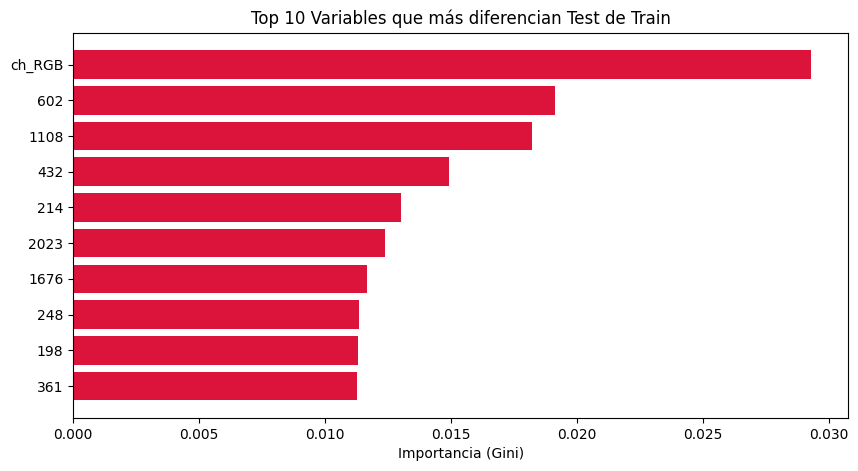

In [28]:
# Entrenamos el modelo con todos los datos para extraer la importancia de las variables
rf_adv.fit(X_adv, y_adv)

# Creamos un DataFrame con la importancia de cada columna
importancias_adv = pd.DataFrame({
    'Variable': X_adv.columns,
    'Importancia': rf_adv.feature_importances_
}).sort_values(by='Importancia', ascending=False)

print("TOP 10 Variables causantes de Covariate Shift:")
print(importancias_adv.head(10))

# Visualización rápida
plt.figure(figsize=(10, 5))
plt.barh(importancias_adv['Variable'].head(10)[::-1], importancias_adv['Importancia'].head(10)[::-1], color='crimson')
plt.title('Top 10 Variables que más diferencian Test de Train')
plt.xlabel('Importancia (Gini)')
plt.show()

In [29]:
# Asumimos que ya tienes la lista 'columnas_a_eliminar' de tu análisis anterior,
# tomadas de importancias_adv
columnas_a_eliminar = importancias_adv['Importancia']

columnas_toxicas = columnas_a_eliminar[:25] # Usa la lista de tu paso adversarial anterior
X_train_drop = x_train.drop(columns=columnas_toxicas, errors='ignore')
X_test_drop = x_test.drop(columns=columnas_toxicas, errors='ignore')

X_train_drop = X_train_drop.drop(['is_test'], axis=1)
X_test_drop = X_test_drop.drop(['is_test'], axis=1)

In [30]:
# ==========================================
# 3. QUANTILE TRANSFORMATION (Adaptación de Dominio)
# ==========================================
qt = QuantileTransformer(output_distribution='normal', n_quantiles=1000, random_state=42)
X_train_qt = pd.DataFrame(qt.fit_transform(X_train_drop), columns=X_train_drop.columns)
X_test_qt = pd.DataFrame(qt.transform(X_test_drop), columns=X_test_drop.columns)

In [31]:
# ==========================================
# 4. EXPERTOS Y SOFT VOTING (Consenso y Soft Margin)
# ==========================================
# Experto 1: SVM con Margen Suave (C más bajo) y probabilidad activada
svm_clf = SVC(
    kernel='rbf', C=10.0, gamma='scale',  # C=10 da flexibilidad, gamma='scale' se adapta al drop
    class_weight='balanced', probability=True, random_state=42
)

# Experto 2: Random Forest (Paradigma Ortogonal)
rf_clf = RandomForestClassifier(
    n_estimators=300, max_depth=12,
    class_weight='balanced', random_state=42, n_jobs=-1
)

# Experto 3: Regresión Logística (Manejo de alta dimensionalidad)
lr_clf = LogisticRegression(
    C=0.1, class_weight='balanced', max_iter=1000, random_state=42
)

# Ensamble Maestro: Votación Suave (Promedio de probabilidades)
# Le damos peso doble (2) al SVM porque sabemos que es tu mejor modelo base
comite = VotingClassifier(
    estimators=[('svm', svm_clf), ('rf', rf_clf), ('lr', lr_clf)],
    voting='soft',
    weights=[2, 1, 1]
)

print("Entrenando el Pipeline Maestro...")
comite.fit(X_train_qt, y_train_full)

Entrenando el Pipeline Maestro...


VotingClassifier(estimators=[('svm',
                              SVC(C=10.0, class_weight='balanced',
                                  probability=True, random_state=42)),
                             ('rf',
                              RandomForestClassifier(class_weight='balanced',
                                                     max_depth=12,
                                                     n_estimators=300,
                                                     n_jobs=-1,
                                                     random_state=42)),
                             ('lr',
                              LogisticRegression(C=0.1, class_weight='balanced',
                                                 max_iter=1000,
                                                 random_state=42))],
                 voting='soft', weights=[2, 1, 1])

In [35]:
# ==========================================
# 5. PREDICCIÓN Y SUBMISSION
# ==========================================
test_preds = comite.predict(X_test_qt)
test_preds_labels = pd.Series(test_preds)

submission = pd.DataFrame({'id': ids_test, 'clase': test_preds_labels})
submission.to_csv('submission_master_pipeline.csv', index=False)
print("¡Archivo 'submission_master_pipeline.csv' generado con éxito!")

¡Archivo 'submission_master_pipeline.csv' generado con éxito!


## Comparacion con datos originales

In [36]:
# 1. Cargamos ambos archivos de entrega (asegúrate de que los nombres coincidan)
sub_antigua = pd.read_csv('/content/drive/MyDrive/DiploDatos_2026/aprendizaje_supervisado/entregable/sample_submission_mask_grupo3_v1.csv') # Tu modelo con StandardScaler
sub_nueva = pd.read_csv('/content/submission_master_pipeline.csv')

# 2. Unimos los dataframes por el ID de la imagen para compararlos lado a lado
comparacion = sub_antigua.merge(sub_nueva, on='id', suffixes=('_Standard', '_Quantile'))

# 3. Calculamos la tasa de desacuerdo
diferencias = comparacion[comparacion['clase_Standard'] != comparacion['clase_Quantile']]
total_imagenes = len(comparacion)
cant_diferencias = len(diferencias)
porcentaje_diferencia = (cant_diferencias / total_imagenes) * 100

print("--- ANÁLISIS DE IMPACTO EN TEST ---")
print(f"Total de imágenes en Test: {total_imagenes}")
print(f"Imágenes que cambiaron de predicción: {cant_diferencias}")
print(f"Tasa de mutación del modelo: {porcentaje_diferencia:.2f}%\n")

if cant_diferencias > 0:
    print("Las imágenes que el QuantileTransformer hizo cambiar de opinión son:")
    print(diferencias)
else:
    print("Ambos modelos predijeron exactamente lo mismo. El QuantileTransformer no alteró la frontera de decisión en la zona del Test.")

--- ANÁLISIS DE IMPACTO EN TEST ---
Total de imágenes en Test: 524
Imágenes que cambiaron de predicción: 2
Tasa de mutación del modelo: 0.38%

Las imágenes que el QuantileTransformer hizo cambiar de opinión son:
      id  clase_Standard  clase_Quantile
311  312               1               0
427  428               1               0
